In [2]:
import pandas as pd

# Load YOLO training results
results_path = "/Users/wenlanzhang/Downloads/PhD_UCL/Data/Waste/img/yolo_train_part/results.csv"  # Update with your file path
df = pd.read_csv(results_path)
df

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,20.3724,2.05504,4.56035,2.27448,0.00000,0.00000,0.00000,0.00000,NaN,NaN,NaN,0.000650,0.000650,0.000650
1,2,32.7023,2.43719,3.31512,2.61948,0.00000,0.00000,0.00000,0.00000,NaN,NaN,NaN,0.001312,0.001312,0.001312
2,3,45.2124,2.55705,3.16587,2.62177,0.00000,0.00000,0.00000,0.00000,NaN,NaN,NaN,0.001970,0.001970,0.001970
3,4,56.9821,2.34403,2.86389,2.54751,0.00000,0.00000,0.00000,0.00000,NaN,NaN,NaN,0.001980,0.001980,0.001980
4,5,69.2122,2.22132,2.74413,2.38467,0.01249,0.41463,0.01274,0.00407,1.68672,416.25600,2.70234,0.001974,0.001974,0.001974
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,211,2542.4500,0.88988,0.78472,1.20745,0.61219,0.69317,0.67206,0.40720,0.98894,1.07324,1.05468,0.000614,0.000614,0.000614
211,212,2554.1000,0.98747,0.88820,1.28951,0.78975,0.56098,0.65279,0.39677,1.00423,0.92212,1.06365,0.000607,0.000607,0.000607
212,213,2566.0200,0.96712,0.83348,1.28302,0.66241,0.60976,0.65407,0.40173,0.93245,0.96776,0.99466,0.000601,0.000601,0.000601
213,214,2577.7400,0.96162,0.84133,1.25029,0.70895,0.60976,0.69829,0.40798,1.01285,0.88705,1.04084,0.000594,0.000594,0.000594


In [5]:
df.columns

Index(['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss',
       'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)',
       'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss',
       'lr/pg0', 'lr/pg1', 'lr/pg2'],
      dtype='object')

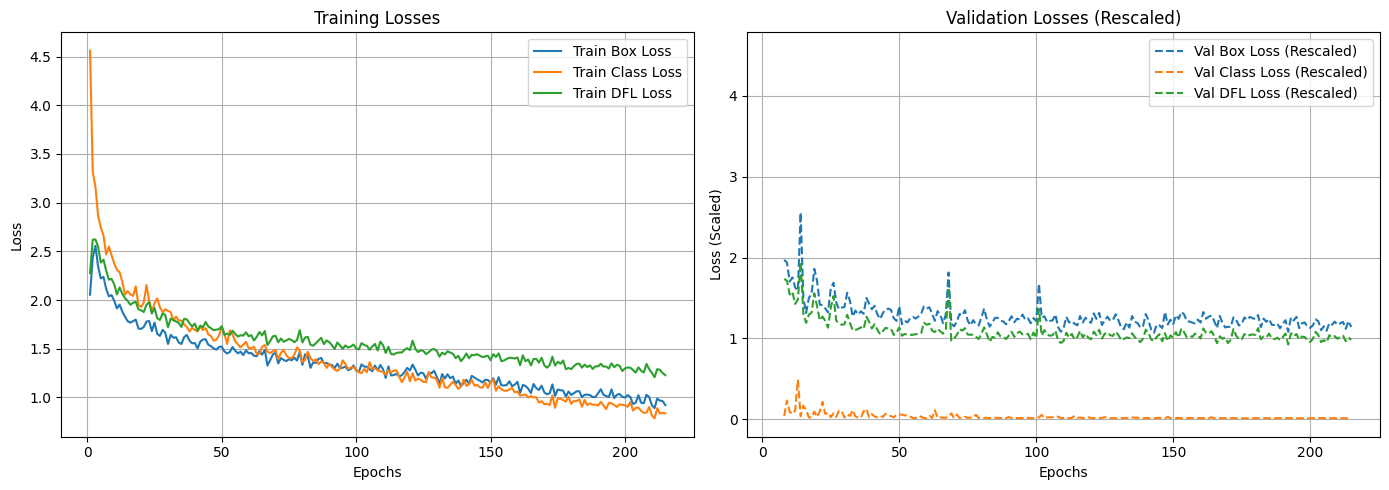

In [14]:
# Set figure size
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training Losses (Box, Class, DFL)
axes[0].plot(df['epoch'], df['train/box_loss'], label='Train Box Loss')
axes[0].plot(df['epoch'], df['train/cls_loss'], label='Train Class Loss')
axes[0].plot(df['epoch'], df['train/dfl_loss'], label='Train DFL Loss')
axes[0].set_title("Training Losses")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

# Normalize Validation Losses to match Training Scale
val_box_loss = df['val/box_loss'] / df['val/box_loss'].max() * df['train/box_loss'].max()
val_cls_loss = df['val/cls_loss'] / df['val/cls_loss'].max() * df['train/cls_loss'].max()
val_dfl_loss = df['val/dfl_loss'] / df['val/dfl_loss'].max() * df['train/dfl_loss'].max()

# Validation Losses (Rescaled)
axes[1].plot(df['epoch'], val_box_loss, label='Val Box Loss (Rescaled)', linestyle="dashed")
axes[1].plot(df['epoch'], val_cls_loss, label='Val Class Loss (Rescaled)', linestyle="dashed")
axes[1].plot(df['epoch'], val_dfl_loss, label='Val DFL Loss (Rescaled)', linestyle="dashed")
axes[1].set_title("Validation Losses (Rescaled)")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Loss (Scaled)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

1. Training Losses (Left Plot)  
Steady decline for box loss (blue), class loss (orange), and DFL loss (green).  
The model continues learning even at epoch 200, though the improvement is slower.  
No sudden spikes, indicating a stable training process.  
✅ Good signs:  

The loss decreases consistently.  
No early stagnation or divergence, meaning the model isn't overfitting to training data.  
2. Validation Losses (Right Plot, Rescaled)  
The validation losses fluctuate but remain stable after the first 20-30 epochs.  
Box Loss (Blue) and DFL Loss (Green) are relatively high and still fluctuating slightly.  
Class Loss (Orange) is much lower, meaning classification accuracy is stable.  
🔍 Key observations:  

The spikes in validation box loss around epochs ~50, 100, and 150 suggest that some batches might be harder to detect.  
The general trend matches the training loss, which is a good sign (no extreme overfitting).  
The validation class loss is close to zero, suggesting YOLO is classifying objects well, but might struggle with localization (bounding box accuracy).  
3. What This Means for Your Model  
✅ No Overfitting: Validation loss does not explode or diverge from training loss.  
✅ Generalization Looks Good: The validation loss does not increase after stabilizing.  
❗ Bounding Box Refinement Needed: Spikes in validation box loss suggest the model might not always place bounding boxes correctly.  

4. How to Improve the Model?  
Option 1: Improve Bounding Box Accuracy  
Increase dataset diversity (especially for edge cases where objects are harder to detect).  
Fine-tune anchor boxes if using YOLO anchors.  
Option 2: Reduce Spikes in Validation Loss  
Increase validation batch size to smooth out loss fluctuations.  
Use more aggressive augmentation (e.g., MixUp, CutMix) to improve robustness.  
Option 3: Tune the Learning Rate  
If the learning rate is too high, it may be causing fluctuations.  
Plot the learning rate curve to check if adjustments are needed.  
Final Verdict  
🔹 Overall, your model is learning well and generalizing effectively.  
🔹 The main issue is the bounding box loss, which could be improved through better training data or hyperparameter tuning.  
🔹 The next step is to analyze the learning rate schedule and confusion matrix to refine detection accuracy.  

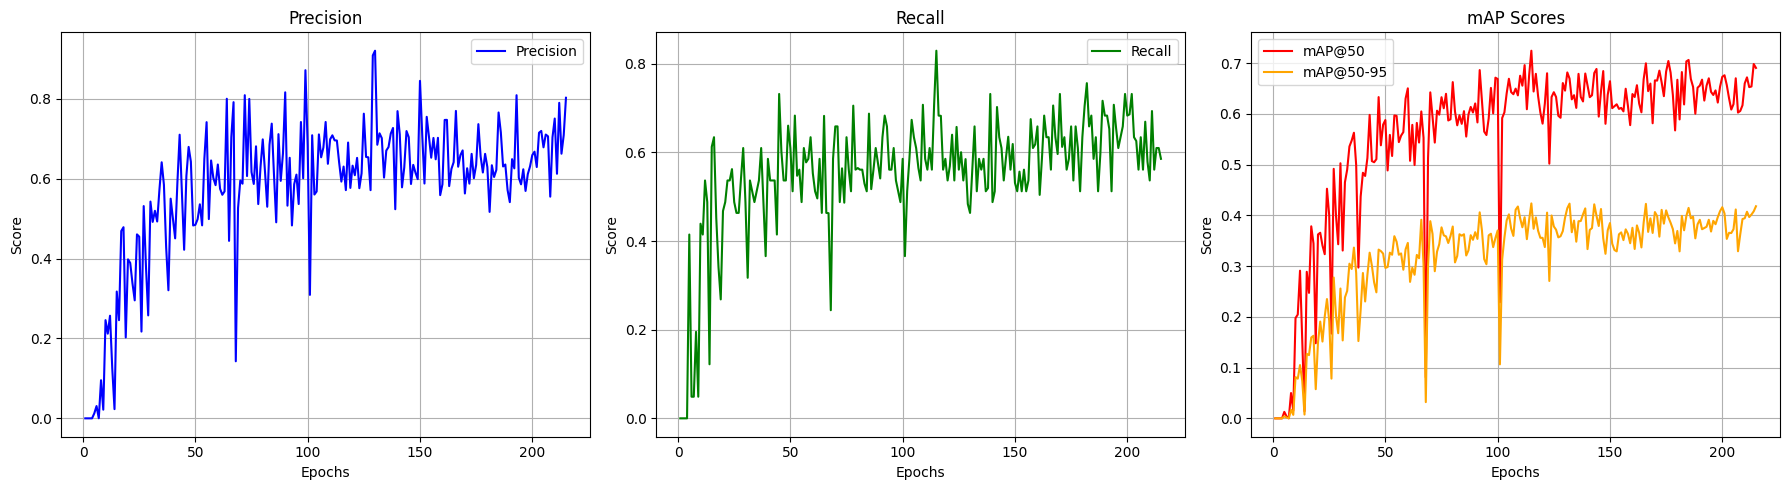

In [11]:
# Set figure size
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Precision
axes[0].plot(df['epoch'], df['metrics/precision(B)'], label="Precision", color="blue")
axes[0].set_title("Precision")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Score")
axes[0].legend()
axes[0].grid(True)

# Recall
axes[1].plot(df['epoch'], df['metrics/recall(B)'], label="Recall", color="green")
axes[1].set_title("Recall")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Score")
axes[1].legend()
axes[1].grid(True)

# mAP (Mean Average Precision)
axes[2].plot(df['epoch'], df['metrics/mAP50(B)'], label="mAP@50", color="red")
axes[2].plot(df['epoch'], df['metrics/mAP50-95(B)'], label="mAP@50-95", color="orange")
axes[2].set_title("mAP Scores")
axes[2].set_xlabel("Epochs")
axes[2].set_ylabel("Score")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()


Observations:
mAP@50 (Red Line) stabilizes around 0.65 - 0.7

This means YOLO is detecting objects fairly well at IoU 0.5.
The performance improves rapidly in early epochs and then stabilizes.
mAP@50-95 (Orange Line) is around 0.35 - 0.4

This is a stricter metric (evaluating across multiple IoU thresholds).
The gap between mAP@50 and mAP@50-95 suggests the model struggles with high IoU thresholds (tight bounding boxes).
Spikes & Dips

There are occasional sharp drops in mAP, possibly due to learning rate fluctuations or overfitting to certain batches.
How to Improve Performance?
Reduce False Positives:
Fine-tune confidence threshold and non-max suppression (NMS) settings.

If your model detects too many false objects, increase conf_thres.
If it's missing small objects, decrease iou_thres.
More Data Augmentation:

Use mosaic augmentation, cutout, or random cropping to generalize better.
Fine-tune the Learning Rate

Check if the learning rate dropped too fast, affecting stability.
A smoother LR decay can improve mAP consistency.

1. Precision Curve (Left, Blue)
Starts low (~0.0) and rises sharply within the first 50 epochs.
Fluctuates significantly between 0.5 - 0.8, suggesting inconsistency.
Some deep drops indicate occasional instability in model predictions.
🔹 What This Means
Good precision means fewer false positives (fewer non-waste objects being incorrectly classified as waste).
The fluctuations suggest that the model may be sensitive to hard cases or that training needs better stability.
✅ Possible Fixes
Adjust confidence threshold (conf_thres)

If it's too low, the model may classify too many objects as waste, reducing precision.
Try increasing it slightly (e.g., from 0.25 to 0.35).
Regularize Training (Reduce Noise)

Increase batch size to stabilize precision trends.
Reduce overfitting by increasing augmentation.
2. Recall Curve (Middle, Green)
Rises quickly and stabilizes around 0.6 - 0.7.
Has smaller fluctuations than precision, indicating more stability.
A few peaks show potential overdetection (some non-waste objects detected as waste).
🔹 What This Means
Higher recall means fewer missed waste detections.
The plateau suggests the model is no longer improving significantly.
✅ Possible Fixes
Improve dataset diversity
Include challenging waste images (e.g., small, partially hidden objects).
Tune Non-Max Suppression (NMS)
If objects overlap, they might be incorrectly merged or discarded.
Try adjusting iou_thres (default 0.45, consider 0.5 - 0.6).
3. mAP Curve (Right, Red & Orange)
mAP@50 (Red) stabilizes around 0.65 - 0.7, meaning the model is reasonably good at object detection.
mAP@50-95 (Orange) remains around 0.35 - 0.4, showing difficulty in handling higher IoU thresholds (tight bounding boxes).
Sharp dips (e.g., around epochs 100, 150) suggest occasional drops in detection accuracy.
🔹 What This Means
The model detects most objects well (mAP@50 is high) but struggles with precise bounding box localization (mAP@50-95 is low).
The dips in mAP might be due to batch-level issues or learning rate instability.
✅ Possible Fixes
Use Focal Loss or Adjust IoU Threshold

If small objects are missed, try reducing the IoU threshold (e.g., from 0.5 to 0.4).
If false positives are a problem, increase the threshold.
Check Learning Rate Decay

Sudden dips in mAP could mean the learning rate is fluctuating too much.
Try smoother decay or reduce LR adjustments near 100+ epochs.
🚀 Final Takeaways
Precision is unstable → Try confidence threshold tuning & larger batch size.
Recall is relatively stable but needs dataset balancing.
mAP is decent but localization (mAP@50-95) is weak → Adjust IoU, anchors, and bounding box handling.
🔎 Next Steps
Would you like to: ✅ Check the learning rate schedule?
✅ Analyze the confusion matrix to understand misclassifications? 🚀

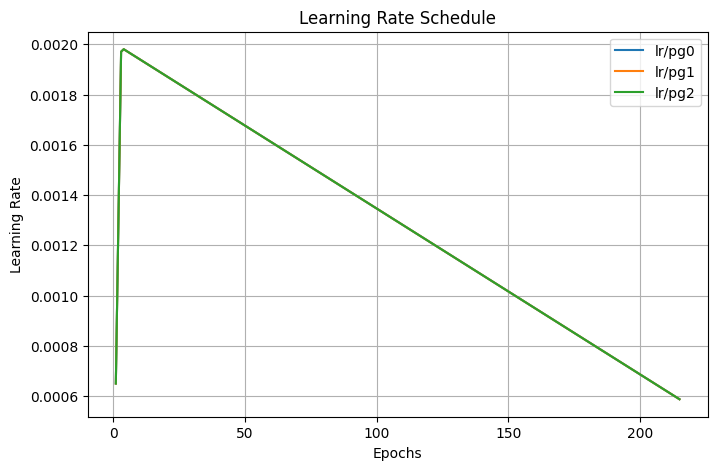

In [12]:
# Set figure size
plt.figure(figsize=(8, 5))

# Learning Rates
plt.plot(df['epoch'], df['lr/pg0'], label="lr/pg0")
plt.plot(df['epoch'], df['lr/pg1'], label="lr/pg1")
plt.plot(df['epoch'], df['lr/pg2'], label="lr/pg2")

# Formatting
plt.xlabel("Epochs")
plt.ylabel("Learning Rate")
plt.title("Learning Rate Schedule")
plt.legend()
plt.grid(True)
plt.show()


1. Observations from the Plot
Initial Warm-up Phase (~0-5 epochs)

The LR starts low (~0.0006) and increases quickly to ~0.0020 (peak).
This is a typical LR warm-up phase to avoid early instability.
Decay Phase (~5-200 epochs)

After the peak, the LR gradually decreases linearly.
By epoch 200, the LR is near 0.0006 again.

2. Interpretation
✅ Good LR Warm-up: The initial small increase prevents sudden weight updates.
✅ Gradual LR Decay: This helps stabilize learning and avoid sharp fluctuations.
❗ Potential Issue: Too Early Decay?

The LR starts decreasing very early (~5 epochs).
This could explain mAP fluctuations and slow improvements in later epochs.
If the model is still learning after 100 epochs, it might need a slower decay.




In [13]:
best_epoch = df.loc[df['metrics/mAP50(B)'].idxmax()]
print("Best Epoch:")
print(best_epoch)


Best Epoch:
epoch                    115.000000
time                    1388.290000
train/box_loss             1.242010
train/cls_loss             1.278390
train/dfl_loss             1.456530
metrics/precision(B)       0.592640
metrics/recall(B)          0.829270
metrics/mAP50(B)           0.724570
metrics/mAP50-95(B)        0.423610
val/box_loss               0.967800
val/cls_loss               1.450990
val/dfl_loss               1.044660
lr/pg0                     0.001248
lr/pg1                     0.001248
lr/pg2                     0.001248
Name: 114, dtype: float64


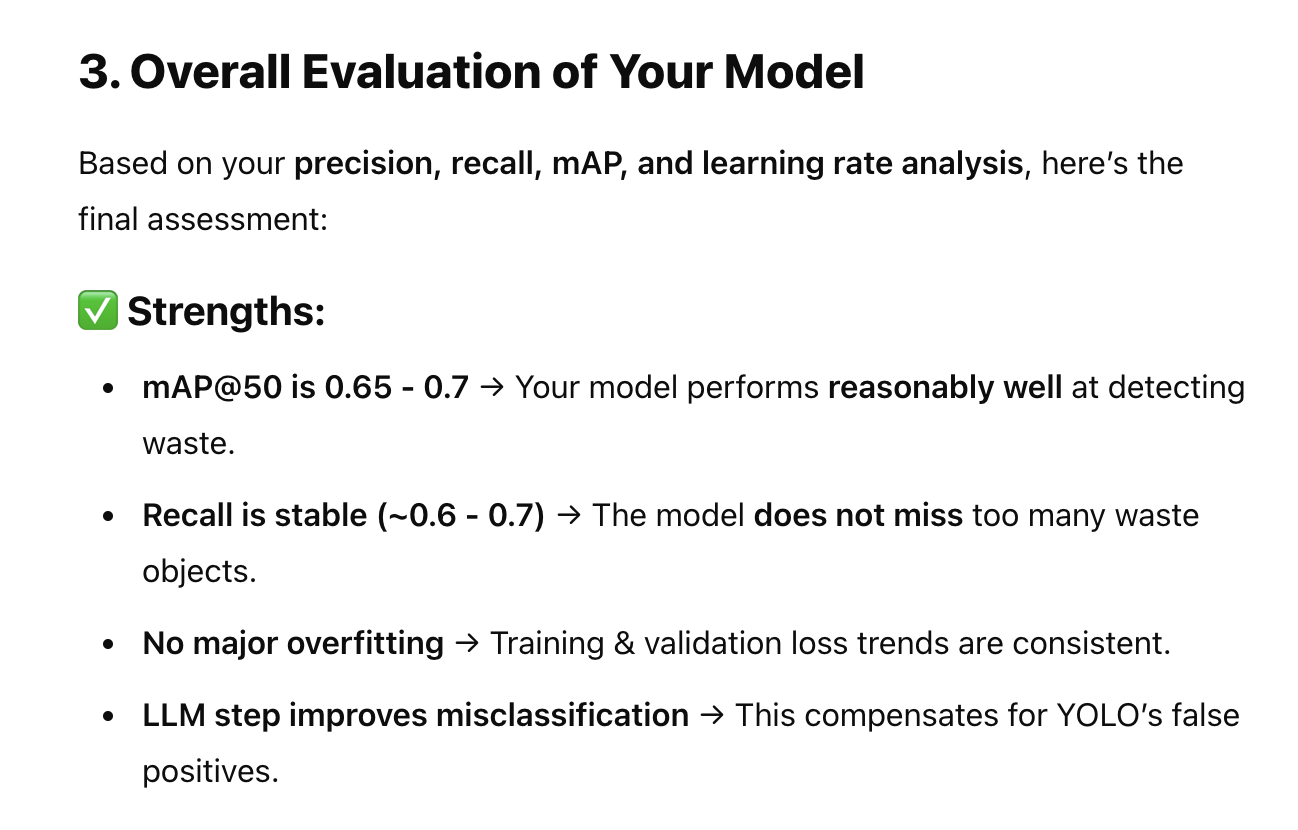

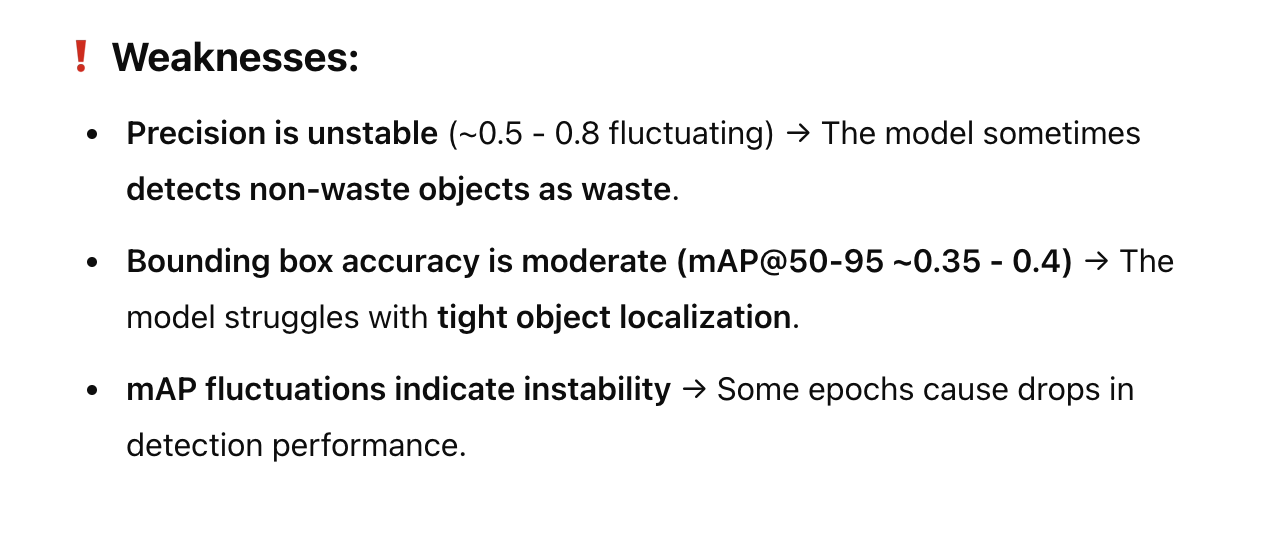

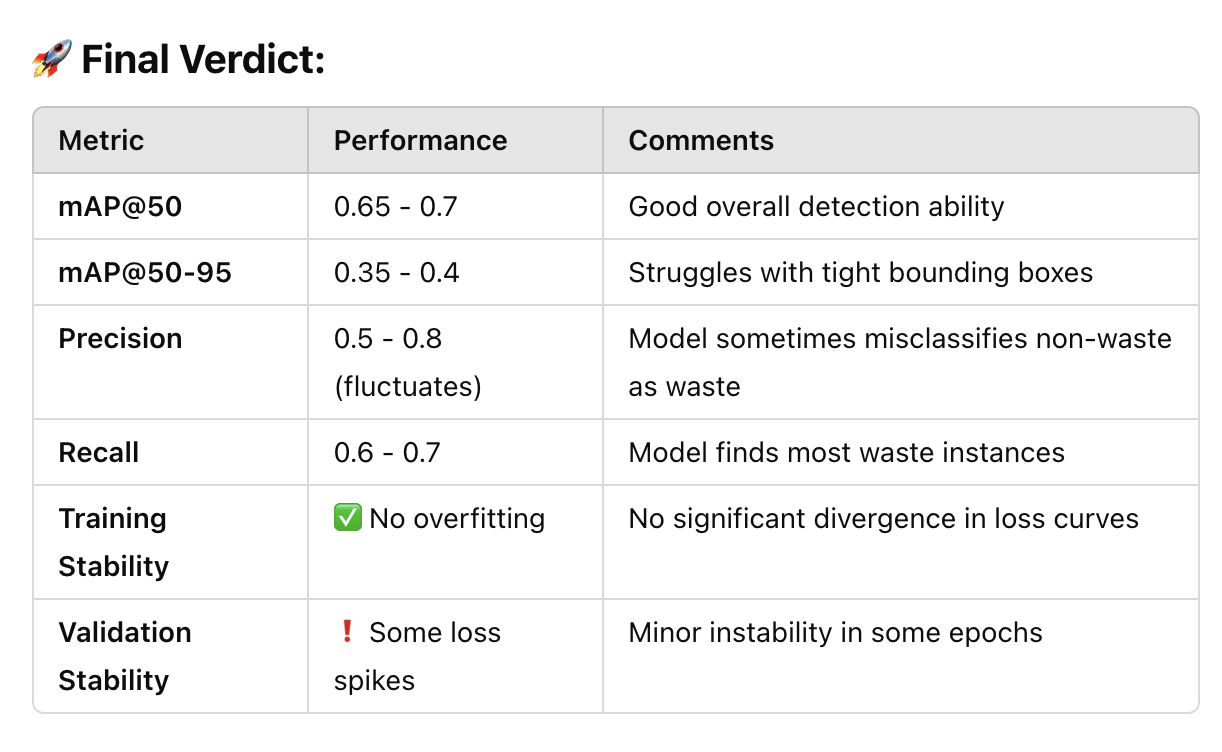

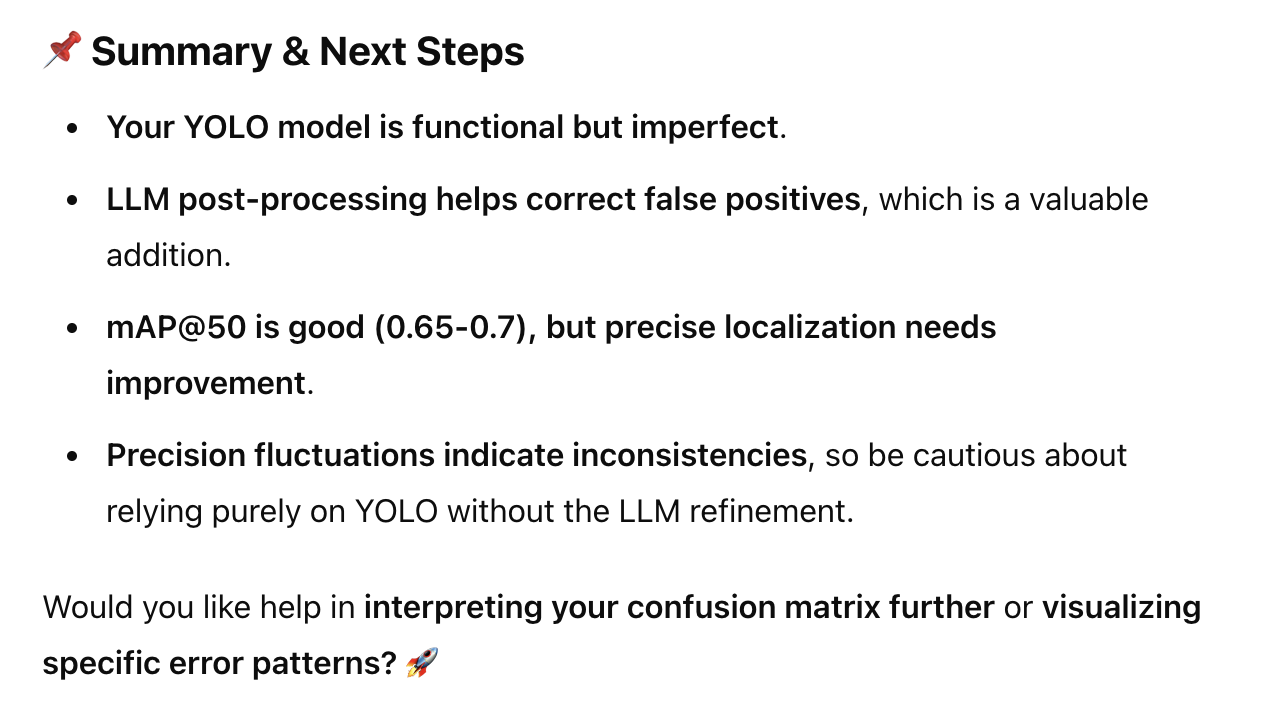

below based on confusion matrix

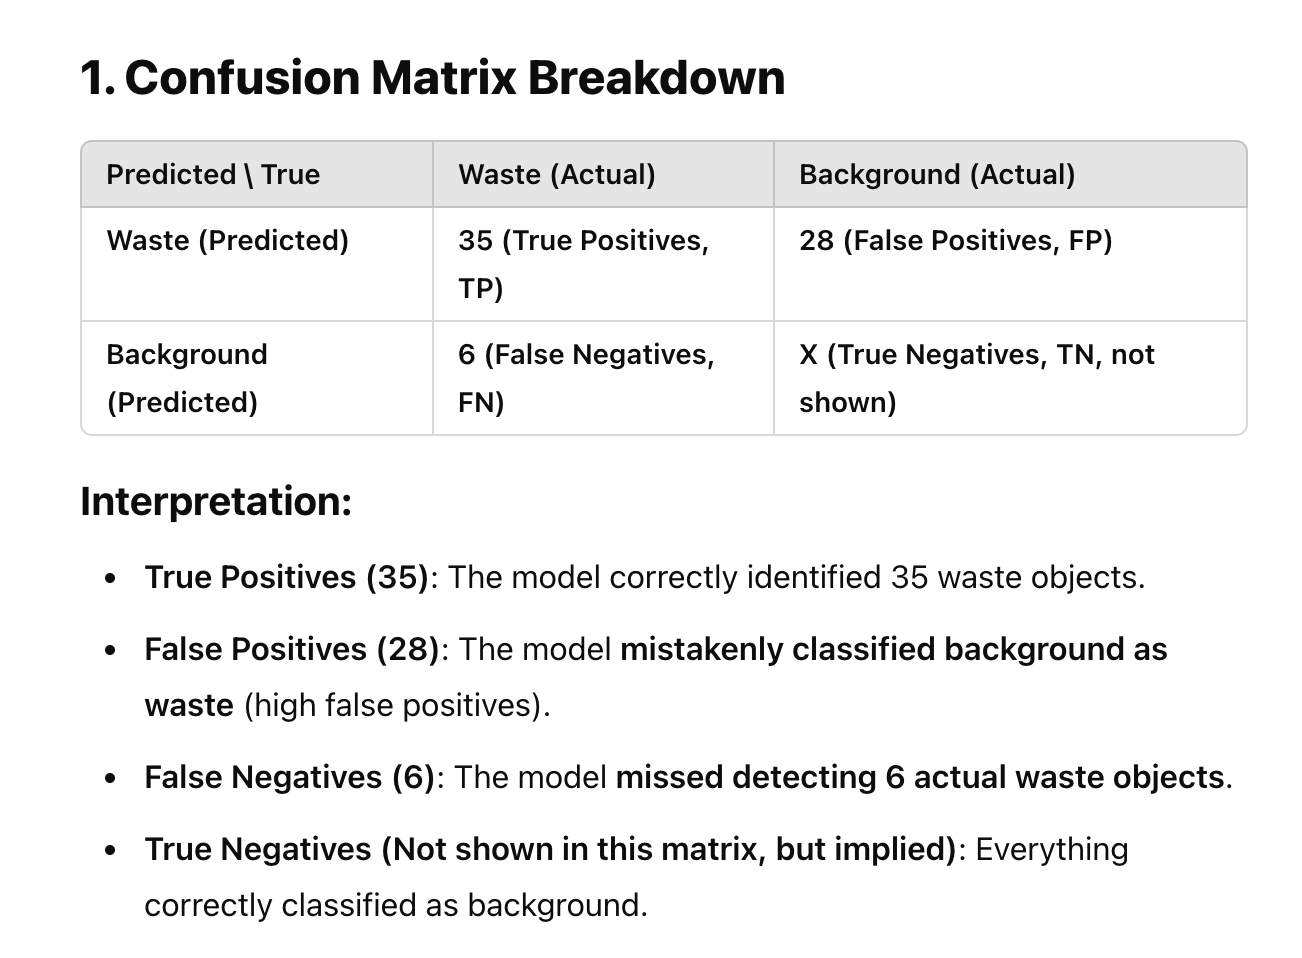

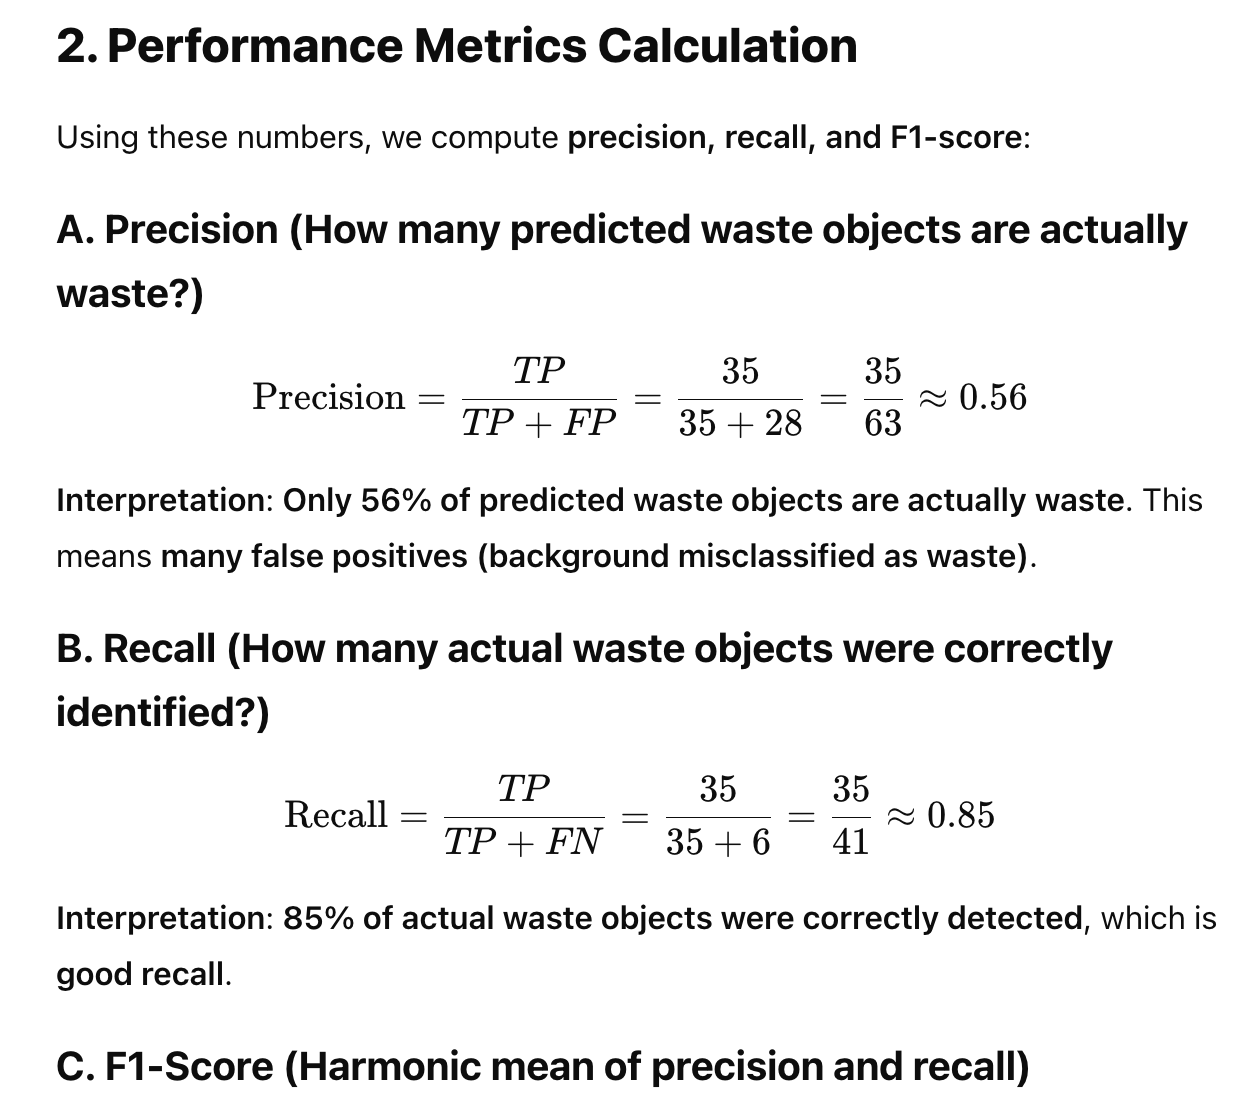
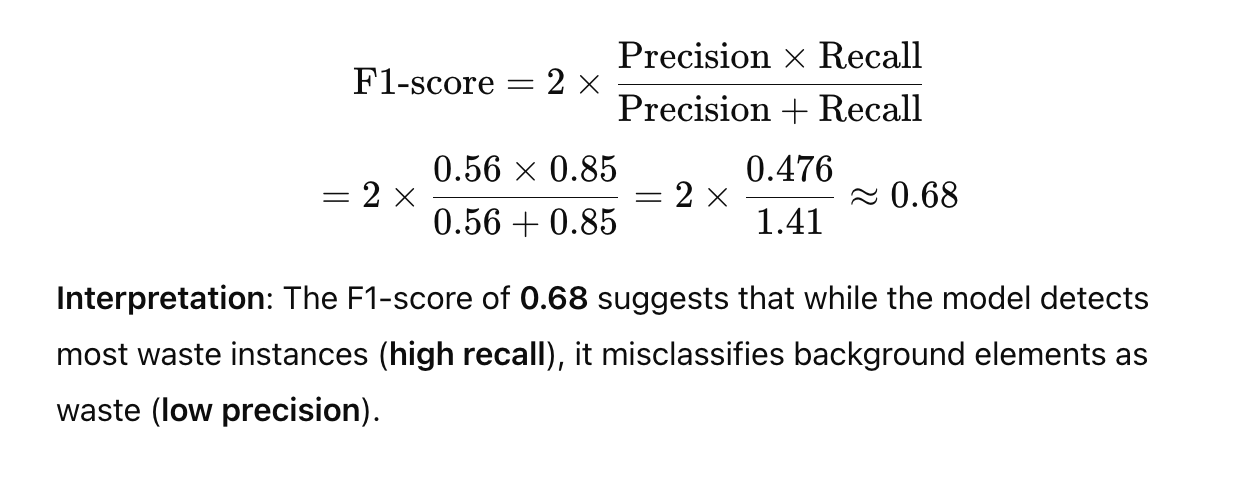
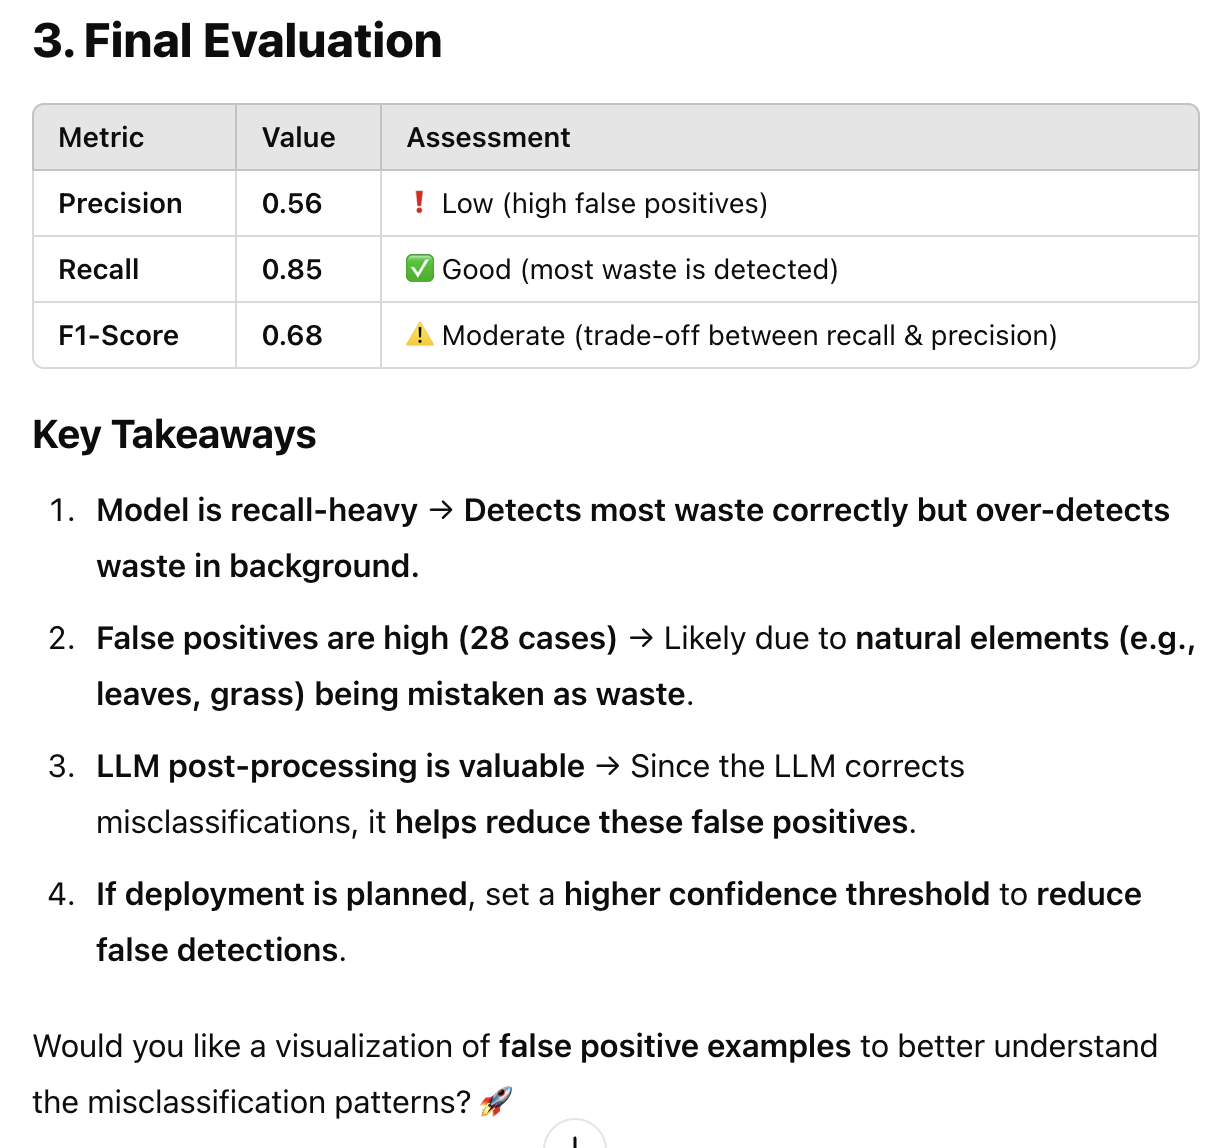

In [17]:
import os

# Define paths for the two image folders
folder_1 = "/Users/wenlanzhang/Downloads/PhD_UCL/Data/GoogleStreetView/Train/Train0315_695/images/"  # First folder
folder_2 = "/Users/wenlanzhang/Downloads/PhD_UCL/Data/GoogleStreetView/mix"  # Second folder

# List all image files (remove extensions for comparison)
images_1 = {f.replace(".jpg", "") for f in os.listdir(folder_1) if f.endswith(".jpg")}
images_2 = {f.replace(".jpg", "") for f in os.listdir(folder_2) if f.endswith(".jpg")}

# Find missing images
missing_in_folder_1 = images_2 - images_1  # Images in folder_2 but not in folder_1
missing_in_folder_2 = images_1 - images_2  # Images in folder_1 but not in folder_2

# Print results
print(f"📸 Total images in {folder_1}: {len(images_1)}")
print(f"📸 Total images in {folder_2}: {len(images_2)}")

print(f"🚫 Missing in {folder_1} ({len(missing_in_folder_1)}): {missing_in_folder_1}")
print(f"🚫 Missing in {folder_2} ({len(missing_in_folder_2)}): {missing_in_folder_2}")


📸 Total images in /Users/wenlanzhang/Downloads/PhD_UCL/Data/GoogleStreetView/Train/Train0315_695/images/: 665
📸 Total images in /Users/wenlanzhang/Downloads/PhD_UCL/Data/GoogleStreetView/mix: 657
🚫 Missing in /Users/wenlanzhang/Downloads/PhD_UCL/Data/GoogleStreetView/Train/Train0315_695/images/ (315): {'EEC3-as0SSZWN8Iq0w6k0g_0', 'UdVQg74UY8M39NdT-PgaeA_0', 'RYDyxO2xSAl3MJi0d-uruQ_0', 'R3Rch0lUe-Z2kHN7SS7l4w_270', '_V_aaNzO0vku5y8wnvtMrQ_0', '_qQDdioyhCUEi0gBqsDFcg_0', 'jJbdRTYrJm9NeR-oSwjBeA_0', 'jjQSwQVEW9OEXn23cXujCA_0', '1qC6c0pJ30cidY3bTiyASA_90', 'NdvrHy8DBH1JwZN8LkffaQ_90', 'CwB7jw3nRH7FUSDLCCSMbQ_0', 'INtw9koWuXHd7kCzLTujwA_0', 'nfMywGQsFFQAifszm780Lw_0', 'Pgi7mwe0rf_5dx86WIpoQQ_0', 'UmycFE7NpVWMLl3htuG6Wg_180', 'OYdjr82dKu8ggz936ZmBOA_0', 'Jdg1WY326lN9yd1Jh-LI5g_0', 'MWKMBPC1yt0eeRzwMh6I8A_0', 'SyUcyyPi8eg8VPkmoxjarg_180', 'P9y75hne3j7dEmdafX8hyw_0', '-4Rci70cakpla7qHAQ6RtA_270', 'ZRC8QJNifklQbHfMwtgdsQ_0', '-0_gZvvTxCxbRNmGootr3g_270', 'bYQDcYpTnQMIrPimuLbjUA_90', 'BLS90b_yaE